# Vitalidad v5 — efecto de la morfología (clasificación nueva: idx + RF)

Notebook **autocontenido**: se ejecuta de arriba abajo. Calcula el índice de vitalidad y mide
el efecto de ser barrio **espontáneo vs planificado** usando las DOS clasificaciones nuevas
(`tipologia_idx` y `tipologia_rf` de `madrid_clasificacion_final_v5.gpkg`).

- Vitalidad = media de 6 dimensiones: variedad de usos, amenidades, asociaciones, rotación, juventud, ocio+restauración.
- Turismo **NO** se controla (forma parte de la ciudad).
- Controles del matching: renta, densidad, centralidad.

In [1]:
import warnings; warnings.filterwarnings('ignore')
import numpy as np, pandas as pd, geopandas as gpd
import matplotlib.pyplot as plt
from scipy.stats import rankdata, t as tdist
from scipy.spatial import cKDTree
import statsmodels.api as sm

BASE   = r'C:\Users\Alvar\OneDrive\Desktop\estudios\economía\Artículos\MQUEA'
GPKG   = BASE + r'\madrid_morfologia_h3_v10.gpkg'
V5     = BASE + r'\Vitalidad\madrid_vitalidad_h3_master_v5.csv'
OCIO   = BASE + r'\Vitalidad\vitalidad_ocio_hex.csv'
CENSO  = BASE + r'\Vitalidad\censo2021_seccen_madrid.gpkg'
CLASIF = BASE + r'\madrid_clasificacion_final_v5.gpkg'
CRS    = 'EPSG:25830'
print('Setup OK')

Setup OK


In [2]:
# ===== 1) Índice de vitalidad (6 dimensiones) =====
gdf = gpd.read_file(GPKG).to_crs(CRS); gdf['hex_id'] = gdf['hex_id'].astype(str)

m = pd.read_csv(V5); m['hex_id'] = m['hex_id'].astype(str)
oc = pd.read_csv(OCIO); oc['hex_id'] = oc['hex_id'].astype(str)
m = m.merge(oc, on='hex_id', how='left')

# Edad por hexágono (Censo 2021, media ponderada por población)
secc = gpd.read_file(CENSO).to_crs(CRS); sp = secc.copy(); sp['geometry'] = secc.geometry.centroid
jd = gpd.sjoin(sp[['pct_menores16','pct_16a64','pob_total','geometry']],
               gdf[['hex_id','geometry']], how='inner', predicate='within')
def wavg(g, c):
    v = g[c].to_numpy(float); w = g['pob_total'].to_numpy(float)
    ok = np.isfinite(v) & np.isfinite(w) & (w > 0)
    return float(np.average(v[ok], weights=w[ok])) if ok.any() else np.nan
ed = pd.DataFrame([(h, wavg(g,'pct_menores16'), wavg(g,'pct_16a64')) for h, g in jd.groupby('hex_id')],
                  columns=['hex_id','pct_menores16','pct_16a64'])
m = m.merge(ed, on='hex_id', how='left')

def prk(s, invert=False):
    s = pd.to_numeric(s, errors='coerce'); ok = s.notna(); r = pd.Series(np.nan, index=s.index)
    if ok.sum(): r[ok] = rankdata(s[ok], method='average') / ok.sum()
    return (1 - r) if invert else r
def dim(*c): return pd.concat(c, axis=1).mean(axis=1)

m['dim1'] = prk(m['div_actividad'])                                      # variedad de usos
m['dim2'] = dim(prk(m['terrazas_ext_km2']), prk(m['n_parques_500m']))    # amenidades
m['dim4'] = prk(m['asoc_km2'])                                           # asociaciones
m['dim5'] = prk(m['cv_pob'])                                             # rotación / dinamismo
m['dim6'] = dim(prk(m['pct_menores16']), prk(m['pct_16a64']))            # juventud (niños + adultos)
m['dim8'] = dim(prk(m['nocturno_km2']), prk(m['restauracion_km2']))      # ocio + restauración
dims = ['dim1','dim2','dim4','dim5','dim6','dim8']
m['vitalidad'] = m[dims].mean(axis=1)
if 'log_airbnb' not in m.columns: m['log_airbnb'] = np.log1p(m['airbnb_ent_km2'])
print('Vitalidad calculada:')
print(m[dims + ['vitalidad']].describe().round(3))

Vitalidad calculada:
           dim1      dim2      dim4      dim5      dim6      dim8  vitalidad
count  2991.000  2991.000  2991.000  1206.000  1239.000  2991.000   2991.000
mean      0.500     0.500     0.500     0.500     0.500     0.500      0.476
std       0.279     0.200     0.248     0.289     0.209     0.203      0.169
min       0.205     0.332     0.320     0.001     0.025     0.336      0.252
25%       0.205     0.332     0.320     0.251     0.345     0.336      0.298
50%       0.511     0.332     0.320     0.500     0.494     0.336      0.444
75%       0.750     0.631     0.750     0.750     0.653     0.603      0.620
max       1.000     0.998     1.000     1.000     0.936     1.000      0.917


In [3]:
# ===== 2) Clasificación morfológica nueva (idx + RF) =====
clf = gpd.read_file(CLASIF)[['hex_id','tipologia_idx','tipologia_rf']]
clf['hex_id'] = clf['hex_id'].astype(str)
m = m.merge(clf, on='hex_id', how='left')
print('tipologia_idx:', m['tipologia_idx'].value_counts(dropna=False).to_dict())
print('tipologia_rf :', m['tipologia_rf'].value_counts(dropna=False).to_dict())

tipologia_idx: {'Planificado': 1356, nan: 1337, 'Espontáneo': 298}
tipologia_rf : {nan: 1337, 'Planificado': 1284, 'Espontáneo': 237, 'Transición': 133}


In [4]:
# ===== 3) Efecto de la morfología sobre la vitalidad (idx y RF) =====
CTRL = ['log_renta','log_densidad','dist_centro_km','log_bc_mean']   # renta + densidad + centralidad (turismo NO)

def efecto(col, nombre):
    d = m[m[col].isin(['Espontáneo','Planificado'])].dropna(subset=['vitalidad']+CTRL).copy()
    d['esp'] = (d[col] == 'Espontáneo').astype(int)
    ne, nc = int(d.esp.sum()), int((d.esp == 0).sum())
    ref = d[d.esp == 0].vitalidad.mean(); sd = d.vitalidad.std()
    raw = d[d.esp == 1].vitalidad.mean() - ref
    # OLS
    X = sm.add_constant(d[['esp']+CTRL].astype(float))
    r = sm.OLS(d['vitalidad'].astype(float), X).fit(cov_type='HC1')
    b, p = r.params['esp'], r.pvalues['esp']
    # Mahalanobis 1:1 sin reemplazo (balance bueno)
    Z = (d[CTRL]-d[CTRL].mean())/d[CTRL].std(); it = d.index[d.esp==1]; ic = d.index[d.esp==0]
    L = np.linalg.cholesky(np.linalg.inv(np.cov(Z.values.T)))
    dist, nn = cKDTree(Z.loc[ic].values@L).query(Z.loc[it].values@L, k=1)
    used, pr = set(), []
    for i in np.argsort(dist):
        c = nn[i]
        if c not in used: pr.append((it[i], ic[c])); used.add(c)
    itm = [a for a,_ in pr]; icm = [bb for _,bb in pr]
    dif = d.loc[itm,'vitalidad'].values - d.loc[icm,'vitalidad'].values
    att = dif.mean(); se = dif.std(ddof=1)/np.sqrt(len(dif)); pa = 2*(1-tdist.cdf(abs(att/se), len(dif)-1))
    def smd(a,b_):
        s = np.sqrt((a.std()**2+b_.std()**2)/2); return abs(a.mean()-b_.mean())/s if s>0 else 0
    bal = {v: round(smd(d.loc[itm,v], d.loc[icm,v]),3) for v in CTRL}
    sig = lambda q: '***' if q<0.001 else '**' if q<0.01 else '*' if q<0.05 else 'n.s.'
    print(f'\n=== {nombre}  (espontáneo={ne}, planificado={nc}) ===')
    print(f'  Diferencia bruta : {raw:+.4f}   ({raw/ref*100:+.1f}%)')
    print(f'  OLS (controlado) : {b:+.4f}   ({b/ref*100:+.1f}%)   p={p:.4f} {sig(p)}   Cohen d={b/sd:.3f}')
    print(f'  Matching Mahalan.: {att:+.4f}   ({att/ref*100:+.1f}%)   p={pa:.4f} {sig(pa)}   (n={len(pr)} pares)')
    print(f'  Balance post (SMD<0.1 = ok): {bal}')

efecto('tipologia_idx', 'NUEVA idx (índice teórico)')
efecto('tipologia_rf',  'NUEVA rf (Random Forest)')


=== NUEVA idx (índice teórico)  (espontáneo=223, planificado=914) ===
  Diferencia bruta : +0.0018   (+0.3%)
  OLS (controlado) : -0.0150   (-2.4%)   p=0.0389 *   Cohen d=-0.129
  Matching Mahalan.: -0.0217   (-3.4%)   p=0.0219 *   (n=185 pares)
  Balance post (SMD<0.1 = ok): {'log_renta': np.float64(0.012), 'log_densidad': np.float64(0.033), 'dist_centro_km': np.float64(0.014), 'log_bc_mean': np.float64(0.014)}

=== NUEVA rf (Random Forest)  (espontáneo=216, planificado=819) ===
  Diferencia bruta : +0.0955   (+15.6%)
  OLS (controlado) : +0.0599   (+9.8%)   p=0.0000 ***   Cohen d=0.516
  Matching Mahalan.: +0.0370   (+6.0%)   p=0.0005 ***   (n=144 pares)
  Balance post (SMD<0.1 = ok): {'log_renta': np.float64(0.002), 'log_densidad': np.float64(0.027), 'dist_centro_km': np.float64(0.016), 'log_bc_mean': np.float64(0.011)}


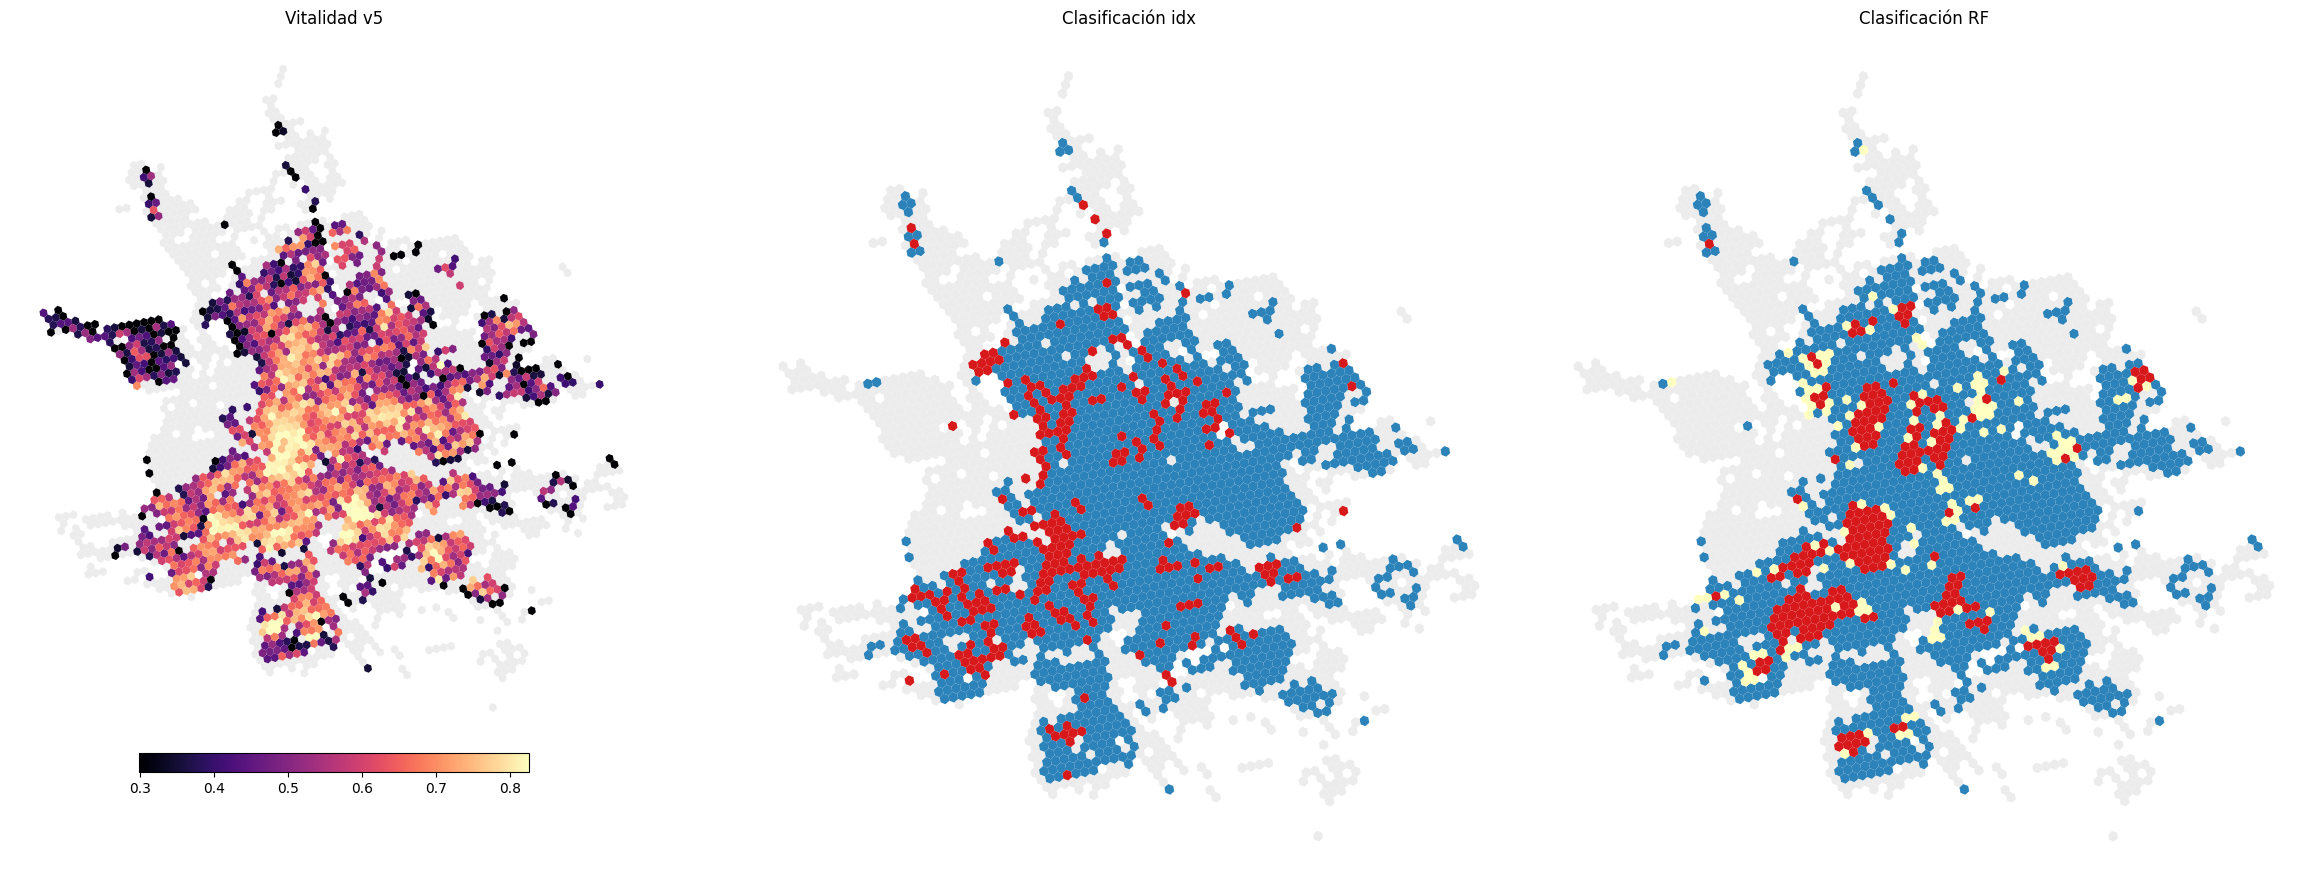

In [5]:
# ===== 4) Mapas: vitalidad + las dos clasificaciones =====
g = gdf.merge(m[['hex_id','vitalidad','tipologia_idx','tipologia_rf']], on='hex_id', how='left')
built = g['cat_n_buildings'].fillna(0) >= 5
disp, grey = g[built], g[~built]
cmap = {'Espontáneo':'#d7191c','Planificado':'#2b83ba','Transición':'#ffffbf'}

fig, ax = plt.subplots(1, 3, figsize=(24, 9))
vmin, vmax = np.nanpercentile(disp['vitalidad'].dropna(), (2, 98))
grey.plot(ax=ax[0], color='#ECECEC', linewidth=0)
disp.plot(column='vitalidad', ax=ax[0], cmap='magma', vmin=vmin, vmax=vmax, linewidth=0,
          legend=True, legend_kwds={'shrink':0.5,'orientation':'horizontal','pad':0.01})
ax[0].set_title('Vitalidad v5'); ax[0].set_axis_off()
for k, (col, tit) in enumerate([('tipologia_idx','Clasificación idx'), ('tipologia_rf','Clasificación RF')]):
    g.plot(color=g[col].map(cmap).fillna('#ECECEC'), ax=ax[k+1], linewidth=0)
    ax[k+1].set_title(tit); ax[k+1].set_axis_off()
plt.tight_layout(); plt.show()

In [6]:
# ===== Vitalidad por TIPOS: comercial vs demográfica =====
m['vit_comercial']   = m[['dim1','dim2','dim8']].mean(axis=1)   # variedad de usos + amenidades + ocio/restauración
m['vit_demografica'] = m[['dim4','dim5','dim6']].mean(axis=1)   # asociaciones + rotación + juventud

def efecto_out(out, col, nombre):
    d = m[m[col].isin(['Espontáneo','Planificado'])].dropna(subset=[out]+CTRL).copy()
    d['esp'] = (d[col]=='Espontáneo').astype(int)
    ne, nc = int(d.esp.sum()), int((d.esp==0).sum())
    ref = d[d.esp==0][out].mean(); sd = d[out].std()
    raw = d[d.esp==1][out].mean() - ref
    X = sm.add_constant(d[['esp']+CTRL].astype(float))
    r = sm.OLS(d[out].astype(float), X).fit(cov_type='HC1'); b, p = r.params['esp'], r.pvalues['esp']
    Z = (d[CTRL]-d[CTRL].mean())/d[CTRL].std(); it = d.index[d.esp==1]; ic = d.index[d.esp==0]
    L = np.linalg.cholesky(np.linalg.inv(np.cov(Z.values.T)))
    dist, nn = cKDTree(Z.loc[ic].values@L).query(Z.loc[it].values@L, k=1)
    used, pr = set(), []
    for i in np.argsort(dist):
        c = nn[i]
        if c not in used: pr.append((it[i], ic[c])); used.add(c)
    itm = [a for a,_ in pr]; icm = [bb for _,bb in pr]
    dif = d.loc[itm,out].values - d.loc[icm,out].values
    att = dif.mean(); se = dif.std(ddof=1)/np.sqrt(len(dif)); pa = 2*(1-tdist.cdf(abs(att/se), len(dif)-1))
    sig = lambda q: '***' if q<0.001 else '**' if q<0.01 else '*' if q<0.05 else 'n.s.'
    print(f'\n=== {nombre}  (esp={ne}, plan={nc}) ===')
    print(f'  Bruto       : {raw/ref*100:+.1f}%')
    print(f'  OLS         : {b/ref*100:+.1f}%   p={p:.4f} {sig(p)}   Cohen d={b/sd:+.2f}')
    print(f'  Mahalanobis : {att/ref*100:+.1f}%   p={pa:.4f} {sig(pa)}   (n={len(pr)} pares)')

CLASIF = 'tipologia_rf'   # cambia a 'tipologia_idx' para el índice teórico
print(f'### Clasificación: {CLASIF} ###')
efecto_out('vit_comercial',   CLASIF, 'VITALIDAD COMERCIAL (dim1+dim2+dim8)')
efecto_out('vit_demografica', CLASIF, 'VITALIDAD DEMOGRÁFICA (dim4+dim5+dim6)')
efecto_out('vitalidad',       CLASIF, 'VITALIDAD TOTAL (referencia)')

### Clasificación: tipologia_rf ###

=== VITALIDAD COMERCIAL (dim1+dim2+dim8)  (esp=216, plan=819) ===
  Bruto       : +13.7%
  OLS         : +6.1%   p=0.0000 ***   Cohen d=+0.26
  Mahalanobis : +4.4%   p=0.0362 *   (n=144 pares)

=== VITALIDAD DEMOGRÁFICA (dim4+dim5+dim6)  (esp=216, plan=819) ===
  Bruto       : +17.9%
  OLS         : +14.3%   p=0.0000 ***   Cohen d=+0.52
  Mahalanobis : +8.1%   p=0.0029 **   (n=144 pares)

=== VITALIDAD TOTAL (referencia)  (esp=216, plan=819) ===
  Bruto       : +15.6%
  OLS         : +9.8%   p=0.0000 ***   Cohen d=+0.52
  Mahalanobis : +6.0%   p=0.0005 ***   (n=144 pares)


In [8]:
# ===== Vitalidad por TIPOS: comercial vs demográfica =====
m['vit_comercial']   = m[['dim1','dim2','dim8']].mean(axis=1)   # variedad de usos + amenidades + ocio/restauración
m['vit_demografica'] = m[['dim4','dim5','dim6']].mean(axis=1)   # asociaciones + rotación + juventud

def efecto_out(out, col, nombre):
    d = m[m[col].isin(['Espontáneo','Planificado'])].dropna(subset=[out]+CTRL).copy()
    d['esp'] = (d[col]=='Espontáneo').astype(int)
    ne, nc = int(d.esp.sum()), int((d.esp==0).sum())
    ref = d[d.esp==0][out].mean(); sd = d[out].std()
    raw = d[d.esp==1][out].mean() - ref
    X = sm.add_constant(d[['esp']+CTRL].astype(float))
    r = sm.OLS(d[out].astype(float), X).fit(cov_type='HC1'); b, p = r.params['esp'], r.pvalues['esp']
    Z = (d[CTRL]-d[CTRL].mean())/d[CTRL].std(); it = d.index[d.esp==1]; ic = d.index[d.esp==0]
    L = np.linalg.cholesky(np.linalg.inv(np.cov(Z.values.T)))
    dist, nn = cKDTree(Z.loc[ic].values@L).query(Z.loc[it].values@L, k=1)
    used, pr = set(), []
    for i in np.argsort(dist):
        c = nn[i]
        if c not in used: pr.append((it[i], ic[c])); used.add(c)
    itm = [a for a,_ in pr]; icm = [bb for _,bb in pr]
    dif = d.loc[itm,out].values - d.loc[icm,out].values
    att = dif.mean(); se = dif.std(ddof=1)/np.sqrt(len(dif)); pa = 2*(1-tdist.cdf(abs(att/se), len(dif)-1))
    sig = lambda q: '***' if q<0.001 else '**' if q<0.01 else '*' if q<0.05 else 'n.s.'
    print(f'\n=== {nombre}  (esp={ne}, plan={nc}) ===')
    print(f'  Bruto       : {raw/ref*100:+.1f}%')
    print(f'  OLS         : {b/ref*100:+.1f}%   p={p:.4f} {sig(p)}   Cohen d={b/sd:+.2f}')
    print(f'  Mahalanobis : {att/ref*100:+.1f}%   p={pa:.4f} {sig(pa)}   (n={len(pr)} pares)')

CLASIF = 'tipologia_idx'   # <-- en vez de 'tipologia_rf'   # cambia a 'tipologia_idx' para el índice teórico
print(f'### Clasificación: {CLASIF} ###')
efecto_out('vit_comercial',   CLASIF, 'VITALIDAD COMERCIAL (dim1+dim2+dim8)')
efecto_out('vit_demografica', CLASIF, 'VITALIDAD DEMOGRÁFICA (dim4+dim5+dim6)')
efecto_out('vitalidad',       CLASIF, 'VITALIDAD TOTAL (referencia)')

### Clasificación: tipologia_idx ###

=== VITALIDAD COMERCIAL (dim1+dim2+dim8)  (esp=223, plan=914) ===
  Bruto       : +1.2%
  OLS         : -2.0%   p=0.1112 n.s.   Cohen d=-0.09
  Mahalanobis : -2.9%   p=0.0623 n.s.   (n=185 pares)

=== VITALIDAD DEMOGRÁFICA (dim4+dim5+dim6)  (esp=223, plan=914) ===
  Bruto       : -0.8%
  OLS         : -2.8%   p=0.1264 n.s.   Cohen d=-0.10
  Mahalanobis : -4.2%   p=0.0791 n.s.   (n=185 pares)

=== VITALIDAD TOTAL (referencia)  (esp=223, plan=914) ===
  Bruto       : +0.3%
  OLS         : -2.4%   p=0.0389 *   Cohen d=-0.13
  Mahalanobis : -3.4%   p=0.0219 *   (n=185 pares)


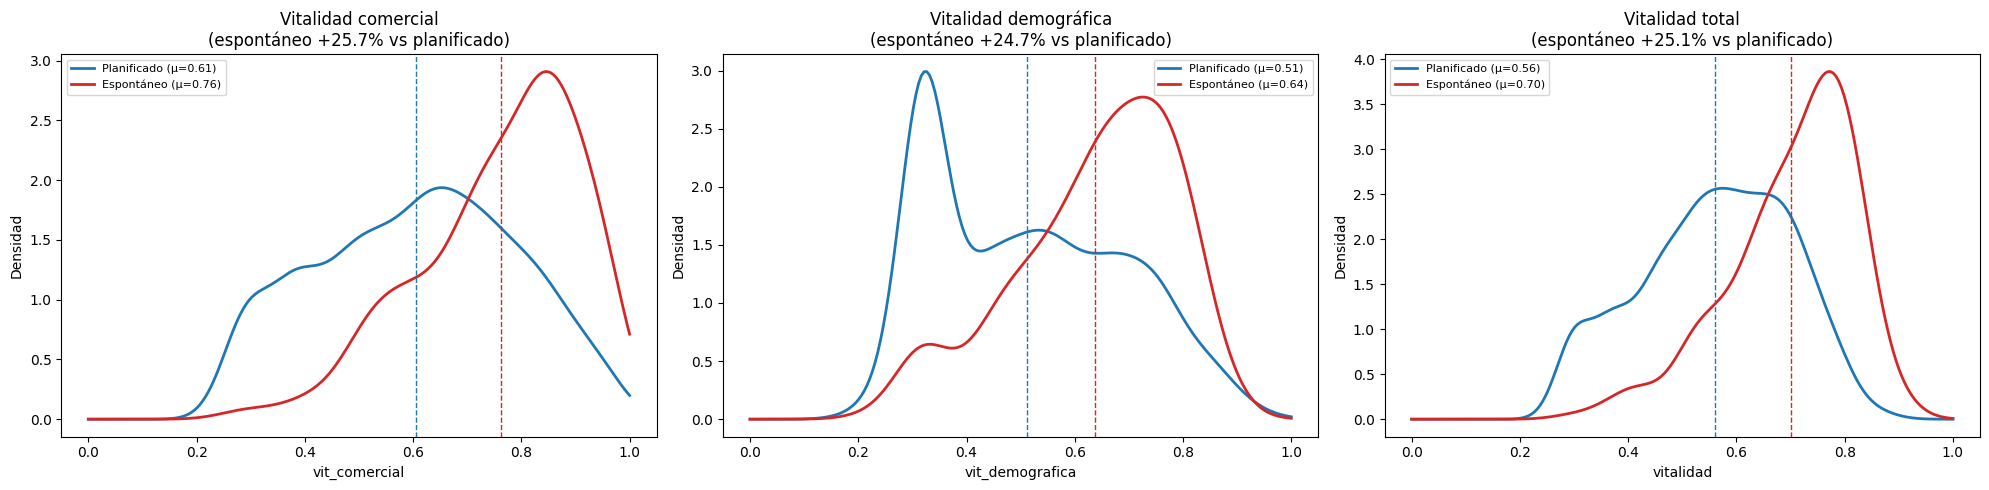

In [7]:
import matplotlib.pyplot as plt, numpy as np
from scipy.stats import gaussian_kde

m['vit_comercial']   = m[['dim1','dim2','dim8']].mean(axis=1)
m['vit_demografica'] = m[['dim4','dim5','dim6']].mean(axis=1)

COL  = 'tipologia_rf'   # cambia a 'tipologia_idx' si quieres el índice teórico
outs = [('vit_comercial',  'Vitalidad comercial'),
        ('vit_demografica','Vitalidad demográfica'),
        ('vitalidad',      'Vitalidad total')]

fig, ax = plt.subplots(1, 3, figsize=(20, 5))
xs = np.linspace(0, 1, 200)
for k, (out, tit) in enumerate(outs):
    e = m.loc[m[COL]=='Espontáneo',  out].dropna().values
    p = m.loc[m[COL]=='Planificado', out].dropna().values
    ax[k].plot(xs, gaussian_kde(p)(xs), color='#1f77b4', lw=2, label=f'Planificado (μ={p.mean():.2f})')
    ax[k].plot(xs, gaussian_kde(e)(xs), color='#d62728', lw=2, label=f'Espontáneo (μ={e.mean():.2f})')
    ax[k].axvline(p.mean(), color='#1f77b4', ls='--', lw=1)
    ax[k].axvline(e.mean(), color='#d62728', ls='--', lw=1)
    dif = (e.mean()-p.mean())/p.mean()*100
    ax[k].set_title(f'{tit}\n(espontáneo {dif:+.1f}% vs planificado)')
    ax[k].set_xlabel(out); ax[k].set_ylabel('Densidad'); ax[k].legend(fontsize=8)
plt.tight_layout(); plt.show()

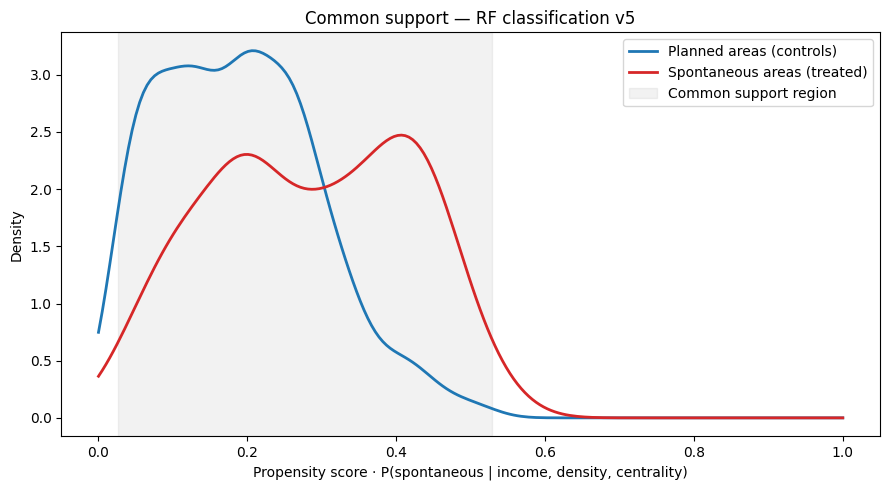

Common support: [0.026, 0.528]  |  outside: 2 spontaneous, 20 planned


In [2]:
xs = np.linspace(0, 1, 200)
fig, ax = plt.subplots(figsize=(9,5))

ax.plot(xs, gaussian_kde(pc)(xs), color='#1f77b4', lw=2,
        label='Planned areas (controls)')

ax.plot(xs, gaussian_kde(pt)(xs), color='#d62728', lw=2,
        label='Spontaneous areas (treated)')

ax.axvspan(lo, hi, color='grey', alpha=0.10,
           label='Common support region')

ax.set_xlabel('Propensity score · P(spontaneous | income, density, centrality)')
ax.set_ylabel('Density')
ax.set_title('Common support — RF classification v5')

ax.legend()
plt.tight_layout()
plt.show()

print(
    f'Common support: [{lo:.3f}, {hi:.3f}]  |  '
    f'outside: {((pt<lo)|(pt>hi)).sum()} spontaneous, '
    f'{((pc<lo)|(pc>hi)).sum()} planned'
)